## Cell 1 — Setup

In [1]:
import torch, os

# Đường dẫn tới thư mục dataset trên máy tính (dùng r ở trước để tránh lỗi \b của Windows)
DATASET_LOCAL = r'D:\bjy2svvmn8-1'

# File model bạn vừa tải về (phải để chung thư mục với file Notebook này)
MODEL_PATH    = 'siamese_best (3).pth'

# Tên file xuất ra
INDEX_SAVE    = 'faiss.index'
META_SAVE     = 'faiss_meta.json'

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'🖥️  Device: {device}')
print(f'📦 Model : {MODEL_PATH}')
print(f'✅ Exists: {os.path.exists(MODEL_PATH)}')

🖥️  Device: cuda
📦 Model : siamese_best (3).pth
✅ Exists: True


## Cell 2 — Cài FAISS

## Cell 3 — Copy dataset về local (nếu chưa có)

In [2]:
import os

if os.path.exists(DATASET_LOCAL):
    # Đếm số lượng ảnh có trong thư mục
    count = sum(len(f) for _,_,f in os.walk(DATASET_LOCAL))
    print(f'✅ Đã kết nối thành công với Dataset tại local!')
    print(f'   Tổng số file tìm thấy: {count}')
else:
    print(f'❌ LỖI: Không tìm thấy thư mục {DATASET_LOCAL}. Vui lòng kiểm tra lại đường dẫn!')

✅ Đã kết nối thành công với Dataset tại local!
   Tổng số file tìm thấy: 3902


## Cell 4 — Load Siamese Model

In [3]:
import torch.nn as nn
import torch.nn.functional as F
from torchvision import models, transforms

# ── Kiến trúc model giữ nguyên ──
class EmbeddingNet(nn.Module):
    def __init__(self, embed_dim=256):
        super().__init__()
        backbone       = models.mobilenet_v2(weights=None)
        self.features  = backbone.features
        self.pool      = nn.AdaptiveAvgPool2d(1)
        self.projector = nn.Sequential(
            nn.Linear(1280, 512), 
            nn.BatchNorm1d(512), # Mới thêm lớp này để đồng bộ với Kaggle
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(512, embed_dim)
        )
    def forward(self, x):
        x = self.pool(self.features(x)).flatten(1)
        return F.normalize(self.projector(x), p=2, dim=1)

class SiameseNetwork(nn.Module):
    def __init__(self, embed_dim=256):
        super().__init__()
        self.net = EmbeddingNet(embed_dim)
    def forward(self, x1, x2):
        return self.net(x1), self.net(x2)
    def get_embedding(self, x):
        return self.net(x)

# Load checkpoint
ck     = torch.load(MODEL_PATH, map_location=device)
EMBED_DIM = ck.get('embed_dim', 256)
model  = SiameseNetwork(EMBED_DIM).to(device)
model.load_state_dict(ck['model_state'])
model.eval()

print(f'✅ Model loaded!')
print(f'   Epoch   : {ck["epoch"]}')
print(f'   Embed dim: {EMBED_DIM}')

# SỬA LẠI THÀNH 384 CHO KHỚP VỚI LÚC TRAIN
IMG_SIZE = 384 

tf = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize([0.485,0.456,0.406],[0.229,0.224,0.225])
])

✅ Model loaded!
   Epoch   : 25
   Embed dim: 256


## Cell 5 — Build FAISS Index

In [4]:
import faiss
import numpy as np
import json
from pathlib import Path
from PIL import Image
from tqdm import tqdm

IMG_EXTS   = {'.jpg', '.jpeg', '.png'}
BATCH_SIZE = 32

# Lấy toàn bộ ảnh
all_imgs = sorted([
    p for p in Path(DATASET_LOCAL).rglob('*')
    if p.suffix.lower() in IMG_EXTS
])
print(f'📂 Tổng ảnh cần encode: {len(all_imgs)}')

# Khởi tạo FAISS index
# IndexFlatL2 = tìm kiếm chính xác theo L2 distance
index    = faiss.IndexFlatL2(EMBED_DIM)
metadata = []  # lưu {class_name, path} theo đúng thứ tự

all_embeddings = []

with torch.no_grad():
# Encode từng batch
    for i in tqdm(range(0, len(all_imgs), BATCH_SIZE), desc='Encoding'):
        batch_paths = all_imgs[i:i+BATCH_SIZE]
        imgs        = []

        for p in batch_paths:
            try:
                img = Image.open(p).convert('RGB')
                imgs.append(tf(img))
            except:
                imgs.append(torch.zeros(3, IMG_SIZE, IMG_SIZE))

        batch = torch.stack(imgs).to(device)
        with torch.no_grad():
            embs = model.get_embedding(batch).cpu().numpy()

        all_embeddings.append(embs)

        for p in batch_paths:
            metadata.append({
                'class_name': p.parent.name,
                'path'      : str(p)
            })

# Add vào FAISS
all_embeddings = np.vstack(all_embeddings).astype(np.float32)
index.add(all_embeddings)

print(f'\n✅ Index built!')
print(f'   Vectors : {index.ntotal}')
print(f'   Metadata: {len(metadata)} entries')

📂 Tổng ảnh cần encode: 3900


Encoding: 100%|██████████| 122/122 [06:33<00:00,  3.23s/it]


✅ Index built!
   Vectors : 3900
   Metadata: 3900 entries


## Cell 6 — Lưu Index xuống Drive

In [5]:
# Lưu FAISS index
faiss.write_index(index, INDEX_SAVE)

# Lưu metadata
with open(META_SAVE, 'w', encoding='utf-8') as f:
    json.dump(metadata, f, ensure_ascii=False, indent=2)

print(f'✅ Đã lưu:')
print(f'   {INDEX_SAVE}')
print(f'   {META_SAVE}')

# Kiểm tra kích thước file
idx_size  = os.path.getsize(INDEX_SAVE)  / 1e6
meta_size = os.path.getsize(META_SAVE)   / 1e6
print(f'   faiss.index    : {idx_size:.2f} MB')
print(f'   faiss_meta.json: {meta_size:.2f} MB')

✅ Đã lưu:
   faiss.index
   faiss_meta.json
   faiss.index    : 3.99 MB
   faiss_meta.json: 0.52 MB


## Cell 7 — Test search thử

Query: Acretin 30 g cream/huawei cn (48).jpg
Top 3 kết quả:
  1. Acretin 30 g cream             dist=0.0000 ✅ IN DB
  2. Acretin 30 g cream             dist=0.0271 ✅ IN DB
  3. Acretin 30 g cream             dist=0.0383 ✅ IN DB


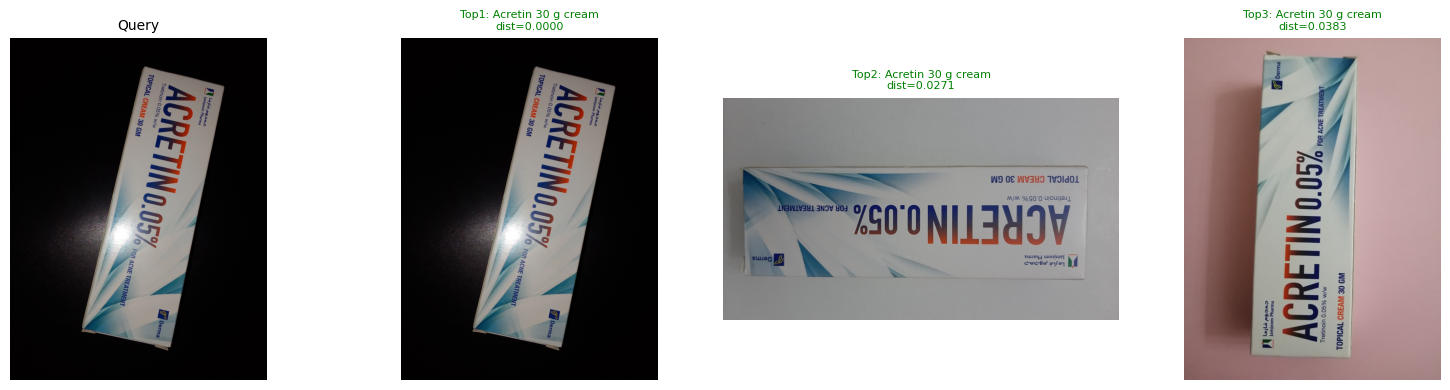


✅ Nếu Top1 cùng class với Query → FAISS hoạt động đúng!


In [6]:
import matplotlib.pyplot as plt

THRESHOLD = 0.5
TOP_K     = 3

def search(image_path, top_k=TOP_K):
    img = Image.open(image_path).convert('RGB')
    x   = tf(img).unsqueeze(0).to(device)
    with torch.no_grad():
        emb = model.get_embedding(x).cpu().numpy().astype(np.float32)

    distances, indices = index.search(emb, top_k)

    results = []
    for dist, idx in zip(distances[0], indices[0]):
        results.append({
            'class_name': metadata[idx]['class_name'],
            'path'      : metadata[idx]['path'],
            'distance'  : round(float(dist), 4),
            'in_db'     : float(dist) < THRESHOLD
        })
    return results


# Lấy 1 ảnh bất kỳ để test
test_img = str(all_imgs[0])
results  = search(test_img)

print(f'Query: {Path(test_img).parent.name}/{Path(test_img).name}')
print(f'Top {TOP_K} kết quả:')
for i, r in enumerate(results):
    status = '✅ IN DB' if r['in_db'] else '❌ NOT IN DB'
    print(f'  {i+1}. {r["class_name"]:30s} dist={r["distance"]:.4f} {status}')

# Visualize
fig, axes = plt.subplots(1, TOP_K + 1, figsize=(4*(TOP_K+1), 4))

axes[0].imshow(Image.open(test_img))
axes[0].set_title('Query', fontsize=10)
axes[0].axis('off')

for i, r in enumerate(results):
    axes[i+1].imshow(Image.open(r['path']))
    color = 'green' if r['in_db'] else 'red'
    axes[i+1].set_title(
        f"Top{i+1}: {r['class_name']}\ndist={r['distance']:.4f}",
        fontsize=8, color=color
    )
    axes[i+1].axis('off')

plt.tight_layout()
plt.show()
print('\n✅ Nếu Top1 cùng class với Query → FAISS hoạt động đúng!')

## Cell 8 — Test với ảnh khác class (kiểm tra threshold)

In [7]:
# Lấy 2 ảnh khác class để kiểm tra threshold
classes   = list(set(m['class_name'] for m in metadata))
cls_a     = classes[0]
cls_b     = classes[1]

img_a = next(p for p in all_imgs if p.parent.name == cls_a)
img_b = next(p for p in all_imgs if p.parent.name == cls_b)

# Encode cả 2
def get_emb(path):
    img = Image.open(path).convert('RGB')
    x   = tf(img).unsqueeze(0).to(device)
    with torch.no_grad():
        return model.get_embedding(x).cpu().numpy().astype(np.float32)

emb_a = get_emb(img_a)
emb_b = get_emb(img_b)

# Ảnh cùng class
imgs_same = [p for p in all_imgs if p.parent.name == cls_a][:2]
emb_same1 = get_emb(imgs_same[0])
emb_same2 = get_emb(imgs_same[1])

dist_same = np.linalg.norm(emb_same1 - emb_same2)
dist_diff = np.linalg.norm(emb_a - emb_b)

print(f'Distance cùng class ({cls_a}): {dist_same:.4f}  ← phải < {THRESHOLD}')
print(f'Distance khác class ({cls_a} vs {cls_b}): {dist_diff:.4f}  ← phải > {THRESHOLD}')
print()

if dist_same < THRESHOLD and dist_diff > THRESHOLD:
    print(f'✅ Threshold={THRESHOLD} hoạt động tốt!')
elif dist_same >= THRESHOLD:
    print(f'⚠️  Threshold quá thấp — thử tăng lên {dist_same + 0.1:.1f}')
else:
    print(f'⚠️  Threshold quá cao — thử giảm xuống {dist_diff - 0.1:.1f}')

Distance cùng class (Diflucan 1 capsule): 0.2323  ← phải < 0.5
Distance khác class (Diflucan 1 capsule vs SelokenZOC 28 tablets): 1.7688  ← phải > 0.5

✅ Threshold=0.5 hoạt động tốt!
